In [1]:
from bam_utils import *

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split, TensorDataset, IterableDataset
from torch.nn import functional as F
from torch.nn import Module, ModuleList
import itertools

from model_0509_vae_cnn import VAE, LargeIterableDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}.")

Using cuda.


In [2]:
mdir = '/home/zouy1/projects/RNAmod/autoencoder/model/template_EM/train_oligos/'
batch_size=256

train_list = mdir+'/train/'
train_list = list(Path(train_list).rglob("*.pt"))
val_list = mdir+'/val/'
val_list = list(Path(val_list).rglob("*.pt"))
test_list = mdir+'/test/'
test_list = list(Path(test_list).rglob("*.pt"))
mod_list =mdir+'/mod/'
mod_list =list(Path(mod_list).rglob("*.pt"))

train_dataset = LargeIterableDataset(train_list, 100000)
val_dataset = LargeIterableDataset(val_list, 20000)
test_dataset = LargeIterableDataset(test_list, 20000)
mod_dataset = LargeIterableDataset(mod_list, 20000)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)
mod_loader  = DataLoader(mod_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

### Training

In [3]:
def loss_function(x, x_hat, mu, logvar, beta=4.0):
    """
    Reconstruction: MSE over all timesteps & features.
    KL divergence:  ½ Σ (μ² + σ² − logσ² −1)
    """
    recon_loss = F.mse_loss(x_hat, x, reduction="mean")
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    loss = recon_loss + beta * kl
    return loss, recon_loss, kl

def loss_function_unbatched(x, x_hat, mu, logvar, beta=4.0):
    """
    x, x_hat : (B, 7, 10)
    mu,logvar: (B, latent_dim)
    returns   : total , recon , kl   each of shape (B,)
    """
    # ── reconstruction loss for each sample ───────────
    # element-wise MSE → (B,7,10)  → mean over time+feat
    mse_map   = F.mse_loss(x_hat, x, reduction='none')      # (B,7,10)
    recon_ps  = mse_map.mean(dim=(1,2))                     # (B,)

    # ── KL divergence per sample ───────────────────────
    # sum over latent dim
    kl_ps = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1)  # (B,)

    # ── total per-sample β-VAE loss ────────────────────
    total_ps = recon_ps + beta * kl_ps                     # (B,)

    return total_ps, recon_ps, kl_ps

In [4]:
"""
Iterative counter–selection loop
================================
• Works with a DataLoader that yields batches shaped (B, 7, 10).
• Uses a pre‑built `model(x)` that returns reconstruction `x_hat`.
• Repeats:
      1) train on current “clean” set
      2) score every window with MSE
      3) drop / down‑weight top‑q% highest‑error windows  (pseudo‑mods)
"""

# ────────────────────────────────────────────────────────────
def recon_loss_per_batch(model, x, beta=4.0):
    """Return per‑sample reconstruction MSE  (B,)"""
    with torch.no_grad():
        x_hat, mu, logvar = model(x)
        loss, rec, kl = loss_function_unbatched(x, x_hat, mu, logvar, beta)
    return loss.cpu()

# ────────────────────────────────────────────────────────────
def score_full_dataset(model, loader, device, beta=4.0):
    """Compute recon‑error for every sample, keep original idx order."""
    model.eval()
    all_scores, all_idx = [], []
    for idx_batch, x in loader:                               # loader must yield (indices, data)
        x = x.to(device)
        loss = recon_loss_per_batch(model, x, beta)
        all_scores.append(loss)
        all_idx.extend(idx_batch.tolist())
    scores = torch.cat(all_scores)                            # (N,)
    return all_idx, scores.numpy()

# ────────────────────────────────────────────────────────────
def build_subset(dataset, keep_idx):
    """Return a PyTorch Subset from indices to keep."""
    return Subset(dataset, sorted(keep_idx))

# ────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, opt, device, beta=4.0):
    model.train()
    epoch_loss = 0.0
    for _, x in loader:
        x  = x.to(device)
        x_hat, mu, logvar = model(x)
        loss, rec, kl = loss_function(x, x_hat, mu, logvar, beta)
        opt.zero_grad()
        loss.backward()
        opt.step()
        epoch_loss += loss.item() * x.size(0)
    return epoch_loss / len(loader.dataset)

# ────────────────────────────────────────────────────────────
class IdxIterableWrapper(IterableDataset):
    """
    Wrap an existing IterableDataset so that each sample is
    yielded as  (global_idx, data_tensor).

    You can supply a set `skip_ids` so these indices are skipped
    (useful after you have flagged pseudo‑mods).
    """
    def __init__(self, base_iterable, skip_ids=None, start_idx=0):
        super().__init__()
        self.base_iterable = base_iterable      # your original dataset
        self.skip_ids      = skip_ids or set()  # indices to drop
        self.start_idx     = start_idx          # optional offset

    def set_skip_ids(self, skip_ids):
        """Update the set of indices to exclude in subsequent epochs."""
        self.skip_ids = set(skip_ids)

    def __iter__(self):
        # itertools.count produces an endless counter 0,1,2,...
        counter = itertools.count(self.start_idx)
        # iterate through the original iterable
        for sample in self.base_iterable:
            idx = next(counter)
            if idx in self.skip_ids:
                continue
            yield idx, sample
            
    def __len__(self) -> int:
        return len(self.base_iterable)-len(self.skip_ids)

In [5]:
def iterative_counter_selection(
        dataset, model,
        device="cuda",
        n_outer=3,
        q_percent=10,        # initial tail %
        q_decay=0.7,         # tail% *= q_decay each round
        inner_epochs=2,
        batch_size=128,
        lr=1e-4,
        beta=4.0):

    full_ds = IdxIterableWrapper(dataset)
    skip_ids = set()                       # cumulative pseudo‑mods

    for it in range(n_outer):
        full_ds.set_skip_ids(skip_ids)     # make wrapper aware of current skip set
        print(f"\n▶  Outer iter {it+1}/{n_outer}   clean windows ≈ {len(dataset)-len(skip_ids)}")

        # 1) train on current clean subset
        clean_loader = DataLoader(full_ds, batch_size=batch_size, drop_last=False)
        opt = torch.optim.Adam(model.parameters(), lr=lr)

        for ep in range(inner_epochs):
            loss = train_one_epoch(model, clean_loader, opt, device, beta)
            print(f"    epoch {ep+1}/{inner_epochs}  recon‑loss={loss:.4f}")

        # 2) score current clean subset
        all_idx, all_scores = score_full_dataset(
            model, DataLoader(full_ds, batch_size=batch_size, drop_last=False), device)

        # 3) trim top‑q% as new pseudo‑mods
        thresh = np.percentile(all_scores, 100 - q_percent)
        new_pseudo = [idx for idx, s in zip(all_idx, all_scores) if s >= thresh]
        skip_ids.update(new_pseudo)        # ⚠ accumulate, don’t overwrite
        print(f"    threshold={thresh:.4f}  →  flagged {len(new_pseudo)} new pseudo‑mods")

        # 4) shrink q for next round
        q_percent *= q_decay

    # After loop, `skip_ids` is full set of pseudo‑mods
    return model, sorted(set(all_idx) - skip_ids), sorted(skip_ids)


In [6]:
# ‑‑ your Dataset must return tensors shaped (7,10) per item
base_dataset = train_dataset

seed=42
torch.manual_seed(seed)

device = 'cuda'

model = VAE(latent_dim=4).to(device)
#model = VAE(latent_dim=1, num_layers=2, hidden_dim=16).to(device)
nparam = sum([p.numel() for p in model.parameters()])
print(f"The total number of params from the current model is {nparam}.")
print("Model running on "+str(next(model.parameters()).device))
print(model)

model, final_clean, final_pseudo = iterative_counter_selection(
        dataset    = base_dataset,
        model      = model,
        device     = "cuda",
        n_outer    = 1,          # EM iterations
        q_percent  = 5,         # start by dropping top 10 % errors
        q_decay    = 0.7,        # 10% → 7% → 5% …
        inner_epochs = 10,
        batch_size   = 256,
        beta         = 0,
        lr           = 1e-3)

# After loop, `model` is trained on progressively cleaner data.


The total number of params from the current model is 17897.
Model running on cuda:0
VAE(
  (enc): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=640, out_features=4, bias=True)
  (fc_logvar): Linear(in_features=640, out_features=4, bias=True)
  (fc_latent): Linear(in_features=4, out_features=640, bias=True)
  (dec): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(0, 1))
    (1): ReLU()
    (2): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

▶  Outer iter 1/1   clean windows ≈ 100000
    epoch 1/10  recon‑loss=0.1108
    epoch 2/10  recon‑loss=0.0578
    epoch 3/10  recon‑loss=0.0509
    epoch 4/10  recon‑loss=0.0474
    epoch 5/10  recon‑loss=0.0454
    epoch 6/10  recon‑loss=0.0439
    epoch 7/10  recon‑loss=0.0427
    e

### Evaluation

In [17]:
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [23]:
def evaluate(model, test_loader, beta=4.0):
    model.eval()
    recon_loss=[]
    
    with torch.no_grad():
        for x in test_loader:
            x = x.to(device)
            x_hat, mu, logvar = model(x)
            loss, rec, kl = loss_function_unbatched(x, x_hat, mu, logvar, beta)
            recon_loss.append(loss.cpu())
    
    recon_loss=torch.concat(recon_loss)
    print(f"{len(recon_loss)} samples evaluated.")
    return recon_loss

c_recon_loss = evaluate(model, test_loader)
mc_recon_loss = evaluate(model, mod_loader)

20000 samples evaluated.
20000 samples evaluated.


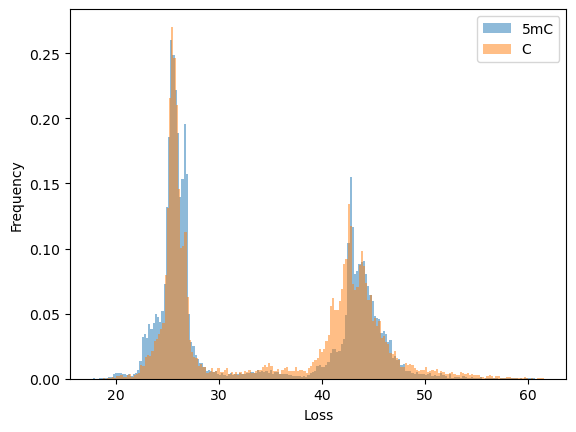

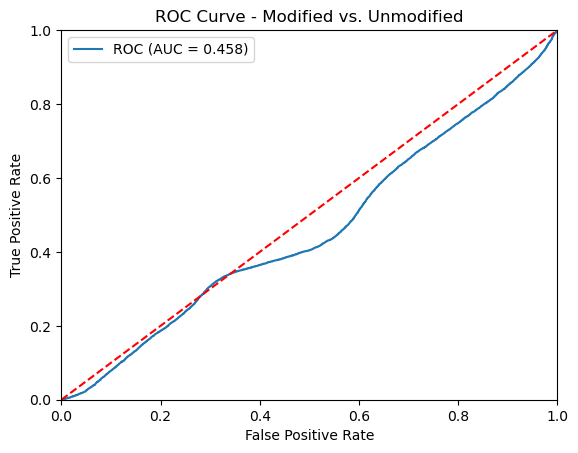

ROC AUC = 0.4583


In [24]:
def plotROC(unmod_loss, mod_loss):
    all_scores = np.concatenate([mod_loss, unmod_loss])
    all_labels = np.concatenate([np.ones_like(mod_loss), np.zeros_like(unmod_loss)])
    
    fpr, tpr, thresholds = roc_curve(all_labels, all_scores)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.3f})")
    plt.plot([0,1],[0,1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve - Modified vs. Unmodified")
    plt.legend()
    plt.show()
    print(f"ROC AUC = {roc_auc:.4f}")
    
def plotHist(unmod_loss, mod_loss):
    plt.hist(mc_recon_loss, bins=200, alpha=0.5, label='5mC', density=True);
    plt.hist(c_recon_loss, bins=200, alpha=0.5, label='C', density=True);
    plt.xlabel("Loss")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()
    
plotHist(c_recon_loss, mc_recon_loss)
plotROC(c_recon_loss, mc_recon_loss)

### Supervised Model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import itertools, numpy as np

# ── 1. Combine two iterable datasets with labels ─────────────────────
class LabeledIterable(IterableDataset):
    """Yield (tensor, label) where label = 0 for unmod, 1 for mod."""
    def __init__(self, iterable_unmod, iterable_mod):
        super().__init__()
        self.iter_unmod = iterable_unmod
        self.iter_mod   = iterable_mod
    def __iter__(self):
        # interleave the two streams 1:1 for balanced batches
        for un, md in itertools.zip_longest(self.iter_unmod, self.iter_mod):
            if un is not None:
                yield un, 0
            if md is not None:
                yield md, 1

# your existing datasets
import random
from pathlib import Path
from torch.utils.data import DataLoader

# ── 1. Build lists of files  ─────────────────────────────────────────
unmod_files = test_list
mod_files   = mod_list

random.seed(42)               # reproducible shuffle

split = 0.2                   # 20 % to test
cut_unmod = int(len(unmod_files) * split)
cut_mod   = int(len(mod_files)   * split)

unmod_test_files = unmod_files[:cut_unmod]
unmod_train_files= unmod_files[cut_unmod:]

mod_test_files   = mod_files[:cut_mod]
mod_train_files  = mod_files[cut_mod:]

# ── 2. Re‑instantiate the datasets  ──────────────────────────────────
train_unmod = LargeIterableDataset(unmod_train_files, n=80000)
train_mod   = LargeIterableDataset(mod_train_files, n=80000)

test_unmod  = LargeIterableDataset(unmod_test_files, n=20000)
test_mod    = LargeIterableDataset(mod_test_files, n=20000)

# ── 3. Wrap with the LabeledIterable helper from previous answer ─────
train_ds = LabeledIterable(train_unmod, train_mod)
test_ds  = LabeledIterable(test_unmod,  test_mod)

train_loader = DataLoader(train_ds, batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

epoch 1  loss=0.6017
epoch 2  loss=0.5893
epoch 3  loss=0.5827
epoch 4  loss=0.5789
epoch 5  loss=0.5766
epoch 6  loss=0.5751
epoch 7  loss=0.5742
epoch 8  loss=0.5736
epoch 9  loss=0.5731
epoch 10  loss=0.5728
Test ROC‑AUC = 0.8366


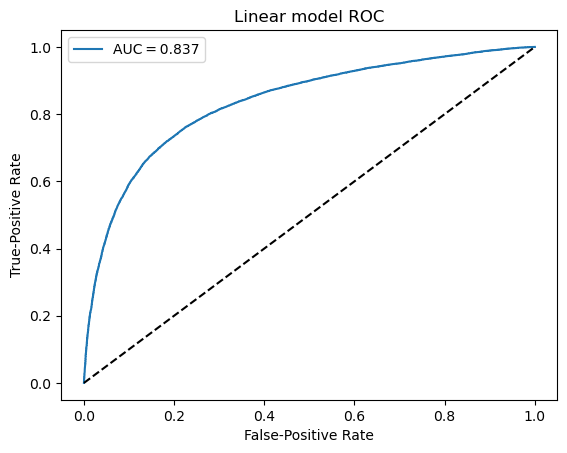

In [15]:
# ── 2. Simple linear classifier ──────────────────────────────────────
class LinearClassifier(nn.Module):
    def __init__(self, in_dim=7*10):
        super().__init__()
        self.fc = nn.Linear(in_dim, 1)           # logits
    def forward(self, x):
        x = x.view(x.size(0), -1)                # flatten (B,70)
        return self.fc(x).squeeze(1)             # (B,)

model = LinearClassifier().cuda()
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ── 3. Training loop (few epochs) ────────────────────────────────────
for epoch in range(10):
    model.train()
    for x, y in train_loader:
        x, y = x.cuda(), y.float().cuda()
        logits = model(x)
        loss = criterion(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    print(f"epoch {epoch+1}  loss={loss.item():.4f}")

# ── 4. Evaluation: collect probs, compute ROC AUC ────────────────────
model.eval()
y_true, y_score = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.cuda()
        logits = model(x)
        probs  = torch.sigmoid(logits).cpu().numpy()
        y_true.extend(y.numpy())
        y_score.extend(probs)

y_true  = np.array(y_true)
y_score = np.array(y_score)
auc     = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

print(f"Test ROC‑AUC = {auc:.4f}")

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False‑Positive Rate"); plt.ylabel("True‑Positive Rate")
plt.title("Linear model ROC"); plt.legend(); plt.show()
